In [1]:
from google.colab import files
import pandas as pd

print("Upload training file")
uploaded_train = files.upload()

print("Upload test file")
uploaded_test = files.upload()

print("Files uploaded successfully")

Upload training file


Saving train-00000-of-00001.parquet to train-00000-of-00001.parquet
Upload test file


Saving test-00000-of-00001.parquet to test-00000-of-00001.parquet
Files uploaded successfully


In [2]:
train_df = pd.read_parquet('train-00000-of-00001.parquet')
test_df = pd.read_parquet('test-00000-of-00001.parquet')

In [3]:
train_df.iloc[0]['text']
train_df.iloc[0]['label']

np.int64(0)

In [4]:
print(train_df.iloc[0]['text'])
train_df['label'].value_counts()

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

,count
label,
0,12500
1,12500


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Baseline model setup started")

Baseline model setup started


In [6]:
tfidf = TfidfVectorizer(max_features=10000)

X_train = tfidf.fit_transform(train_df['text'])
X_test = tfidf.transform(test_df['text'])

y_train = train_df['label']
y_test = test_df['label']

print("TF-IDF conversion completed")
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

TF-IDF conversion completed
Training data shape: (25000, 10000)
Test data shape: (25000, 10000)


In [7]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

print("Baseline model training completed")

Baseline model training completed


In [8]:
baseline_predictions = baseline_model.predict(X_test)

accuracy = accuracy_score(y_test, baseline_predictions)
precision = precision_score(y_test, baseline_predictions)
recall = recall_score(y_test, baseline_predictions)
f1 = f1_score(y_test, baseline_predictions)

print("Baseline Model Results")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Baseline Model Results
Accuracy : 0.8837
Precision: 0.8844
Recall   : 0.8828
F1 Score : 0.8836


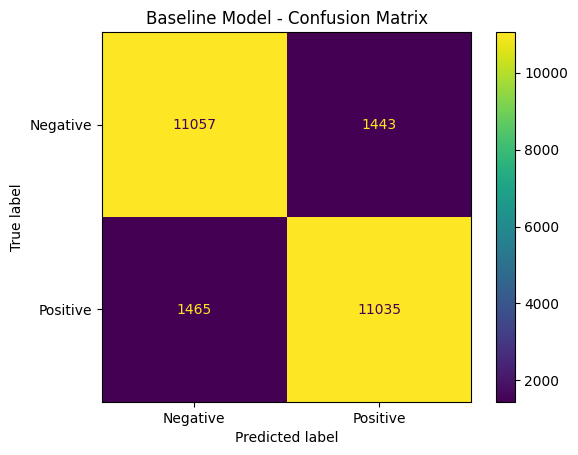

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, baseline_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

display.plot()
plt.title("Baseline Model - Confusion Matrix")
plt.show()

In [10]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [11]:
train_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [14]:
tokenized_train

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 25000
})

In [15]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {'accuracy': acc, 'f1': f1}

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy'
)

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.263761,0.258537,0.894120,0.893758


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.263761,0.258537,0.894120,0.893758
2,0.120833,0.303702,0.911800,0.911799


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3126, training_loss=0.22220947615854722, metrics={'train_runtime': 1375.0719, 'train_samples_per_second': 36.362, 'train_steps_per_second': 2.273, 'total_flos': 3311684966400000.0, 'train_loss': 0.22220947615854722, 'epoch': 2.0})

In [17]:
results = trainer.evaluate(tokenized_test)
print(results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.120833,0.303702,2,0.911800,0.911799


{'eval_loss': 0.3037022352218628, 'eval_accuracy': 0.9118, 'eval_f1': 0.9117988821743132}


In [18]:
import numpy as np

predictions = trainer.predict(tokenized_test)

distilbert_predictions = np.argmax(predictions.predictions, axis=1)
distilbert_labels = predictions.label_ids

print("DistilBERT predictions generated")
print("Number of predictions:", len(distilbert_predictions))

DistilBERT predictions generated
Number of predictions: 25000


In [19]:
accuracy = accuracy_score(distilbert_labels, distilbert_predictions)
precision = precision_score(distilbert_labels, distilbert_predictions)
recall = recall_score(distilbert_labels, distilbert_predictions)
f1 = f1_score(distilbert_labels, distilbert_predictions)

print("DistilBERT Results")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

DistilBERT Results
Accuracy : 0.9118
Precision: 0.9089
Recall   : 0.9154
F1 Score : 0.9121


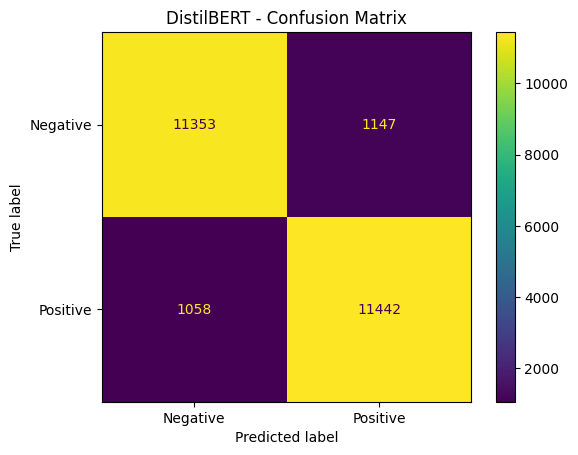

In [20]:
cm = confusion_matrix(distilbert_labels, distilbert_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

display.plot()
plt.title("DistilBERT - Confusion Matrix")
plt.show()

In [21]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "Fine-tuned DistilBERT"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_predictions),
        accuracy_score(distilbert_labels, distilbert_predictions)
    ],
    "Precision": [
        precision_score(y_test, baseline_predictions),
        precision_score(distilbert_labels, distilbert_predictions)
    ],
    "Recall": [
        recall_score(y_test, baseline_predictions),
        recall_score(distilbert_labels, distilbert_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, baseline_predictions),
        f1_score(distilbert_labels, distilbert_predictions)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression,0.8837,0.8844,0.8828,0.8836
1,Fine-tuned DistilBERT,0.9118,0.9089,0.9154,0.9121


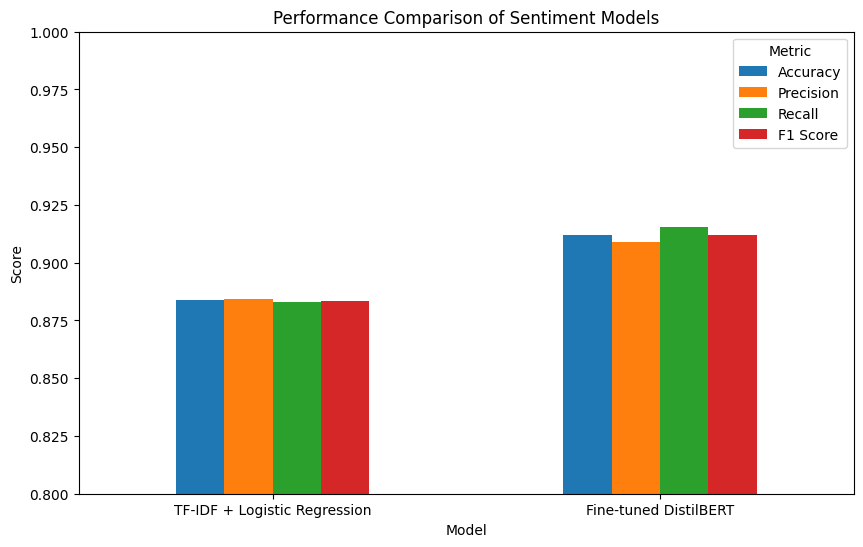

In [22]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Sentiment Models")
plt.ylabel("Score")
plt.ylim(0.80, 1.00)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

In [23]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256)
    inputs = {key: value.to('cuda') for key, value in inputs.items()}
    outputs = model(**inputs)
    predictions = outputs.logits.argmax(dim=1).item()
    return predictions

review1 = "This movie was amazing. Great acting and wonderful story."
review2 = "Terrible film. Waste of time and money."
review3 = "It was okay, nothing special but watchable."

print(predict_sentiment(review1))
print(predict_sentiment(review2))
print(predict_sentiment(review3))

1
0
0


In [24]:
test_reviews = [
    "The cinematography was breathtaking, a visual masterpiece.",
    "The plot made no sense at all, completely confusing.",
    "I laughed throughout, one of the best comedies I have seen.",
    "The acting was wooden and the dialogue was boring."
]

for review in test_reviews:
    pred = predict_sentiment(review)
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"Review: {review}")
    print(f"Prediction: {sentiment}")
    print("-" * 40)

Review: The cinematography was breathtaking, a visual masterpiece.
Prediction: Positive
----------------------------------------
Review: The plot made no sense at all, completely confusing.
Prediction: Negative
----------------------------------------
Review: I laughed throughout, one of the best comedies I have seen.
Prediction: Positive
----------------------------------------
Review: The acting was wooden and the dialogue was boring.
Prediction: Negative
----------------------------------------


In [25]:
model.save_pretrained('./sentiment_model')
tokenizer.save_pretrained('./sentiment_model')

from google.colab import files
import shutil
import os

shutil.make_archive('sentiment_model', 'zip', './sentiment_model')
files.download('sentiment_model.zip')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from google.colab import files
import os

os.makedirs('./sentiment_model', exist_ok=True)

print("Upload config.json")
files.upload()

print("Upload model.safetensors")
files.upload()

print("Upload tokenizer.json")
files.upload()

print("Upload tokenizer_config.json")
files.upload()

Upload config.json


Saving config[1].json to config[1].json
Upload model.safetensors


Saving model[1].safetensors to model[1].safetensors
Upload tokenizer.json


Saving tokenizer[1].json to tokenizer[1].json
Upload tokenizer_config.json


Saving tokenizer[1].json to tokenizer[1] (1).json


{'tokenizer[1] (1).json': b'{\n  "version": "1.0",\n  "truncation": {\n    "direction": "Right",\n    "max_length": 256,\n    "strategy": "LongestFirst",\n    "stride": 0\n  },\n  "padding": null,\n  "added_tokens": [\n    {\n      "id": 0,\n      "content": "[PAD]",\n      "single_word": false,\n      "lstrip": false,\n      "rstrip": false,\n      "normalized": false,\n      "special": true\n    },\n    {\n      "id": 100,\n      "content": "[UNK]",\n      "single_word": false,\n      "lstrip": false,\n      "rstrip": false,\n      "normalized": false,\n      "special": true\n    },\n    {\n      "id": 101,\n      "content": "[CLS]",\n      "single_word": false,\n      "lstrip": false,\n      "rstrip": false,\n      "normalized": false,\n      "special": true\n    },\n    {\n      "id": 102,\n      "content": "[SEP]",\n      "single_word": false,\n      "lstrip": false,\n      "rstrip": false,\n      "normalized": false,\n      "special": true\n    },\n    {\n      "id": 103,\n      

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = "./sentiment_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

def predict(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256)
    outputs = model(**inputs)
    pred = outputs.logits.argmax(dim=1).item()
    return pred

reviews = [
    "This movie was amazi
    ng",
    "Waste of time",
    "Decent film"
]

for review in reviews:
    pred = predict(review)
    print(f"{review} -> {'Positive' if pred == 1 else 'Negative'}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

This movie was amazing -> Positive
Waste of time -> Negative
Decent film -> Negative
